In [1]:
import xarray as xr
import rioxarray as rio
import matplotlib.pyplot as plt
import os
from glob import glob
import rasterio as ras
from pathlib import Path as pa
from multiprocessing import Pool
import multiprocessing

In [2]:
def process_file(file_path):
    try:
        ds = rio.open_rasterio(file_path)
        binary = ds+1
        # Preserve all attributes and metadata
        binary.attrs = ds.attrs.copy()  # Copy all attributes
        binary.name = 'water_irrigated_rainfed_natural'  # Optional: give it a new name
        
        # Preserve coordinates and dimensions
        # if not os.path.isdir(str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}')):
            # os.makedirs(str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}'))
        # out_path = str(pa(file_path).parent.parent / f'binary_{pa(file_path).parent.name}' / pa(file_path).name)
        out_path = f'/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/validation_chips/{pa(file_path).name}'
        binary = binary.assign_coords(ds.coords)
        binary.rio.to_raster(out_path, driver='GTiff', dtype='uint8', nodata=ds.rio.nodata)
        return f"Success: {file_path}"
    except Exception as e:
        return print(f'there was an error reading the file: {str(e)}')

In [3]:
def plot_bin(file_path):
    # Quick visualization
    ds = rio.open_rasterio(file_path)
    binary = ds+1
    # Preserve all attributes and metadata
    binary.attrs = ds.attrs.copy()  # Copy all attributes
    binary.name = 'water_irrigated_rainfed_natural'  # Optional: give it a new name
    from matplotlib.colors import ListedColormap
    plt.rcParams.update({'font.size': 14})
    colors = ['#1f77b4', '#2ca02c', '#98df8a', '#8c564b'] 
    cmap = plt.cm.colors.ListedColormap(colors)
    # Create the plot
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # Plot the data
    im = binary.plot(
        x='x',
        cmap=cmap,
        add_colorbar=False,  # We'll add our own colorbar
        ax=ax,
        vmin =1,
        vmax =4
    )
    
    # # Add a colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=[1.375, 2.125, 2.875, 3.625])  # Center of each color band
    cbar.ax.set_yticklabels(['Water', 'Irrigated', 'Rainfed', 'Natural landcover'])
    
    # Add title and labels
    plt.title('Land Cover and Irrigation Classification')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    fig.autofmt_xdate()

Processing 766 files with 47 workers
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_125_303.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_335_506.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_061_194.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_186_511.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_330_516.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_379_348.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_210_277.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_171_521.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_126_446.mask.tif
Success: /discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/chip_164_481.mask.tif
Success: /discover/nobackup/ejalilva/data/p

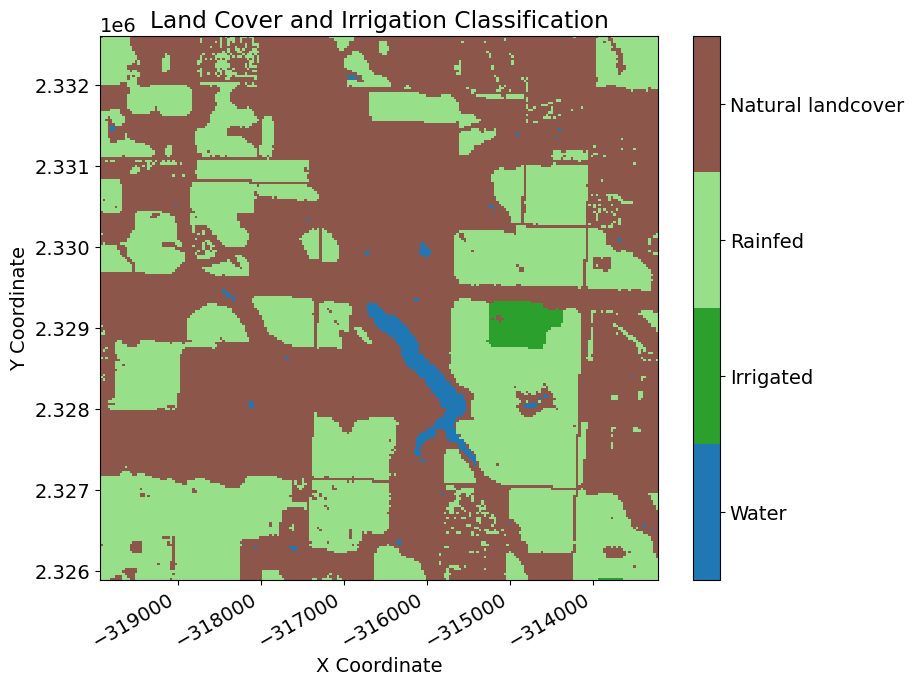

In [4]:
if __name__ == "__main__":
   
    dataset_folder_path = '/discover/nobackup/ejalilva/data/prithvi/ir_validation_chips/'
    files = glob(os.path.join(dataset_folder_path,'*.mask.tif'))
    n_workers = max(1, multiprocessing.cpu_count() - 1)
    print(f"Processing {len(files)} files with {n_workers} workers")
    
    with Pool(n_workers) as pool:
        results = pool.map(process_file, files)
    
    # Print results
    for result in results:
        print(result)
    plot_bin(files[0]) 

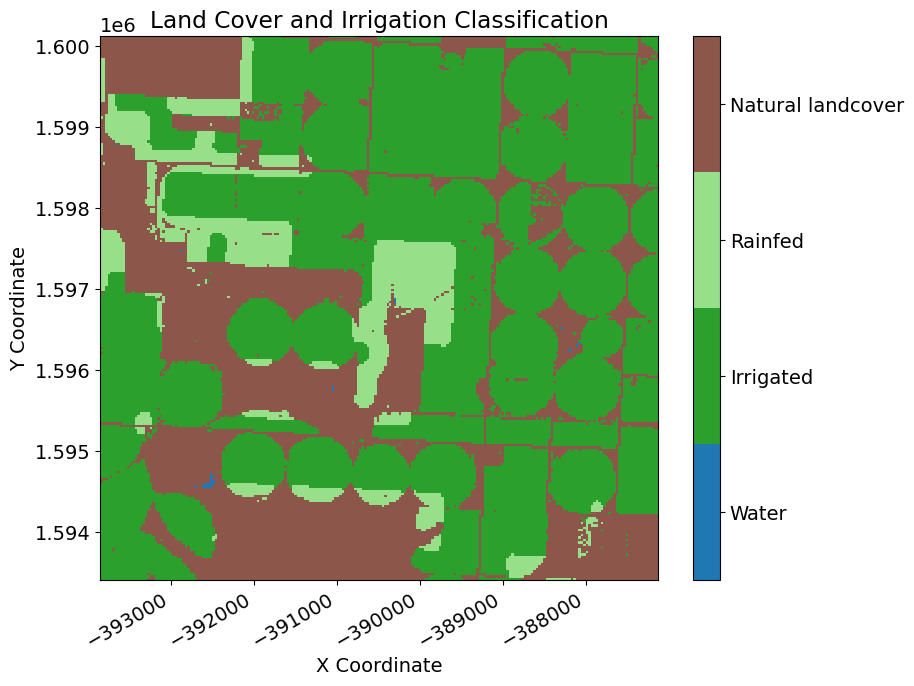

In [5]:
plot_bin(files[120])

In [95]:
dataset_folder_path = '/discover/nobackup/ejalilva/data/prithvi/datasets--ibm-nasa-geospatial--multi-temporal-irrigation-classificaction/snapshots/04b439f179e52a7b144f69676210eecd30c39cfc/training_chips/'
files = glob(os.path.join(dataset_folder_path,'*mask.tif'))
len(files)

3058

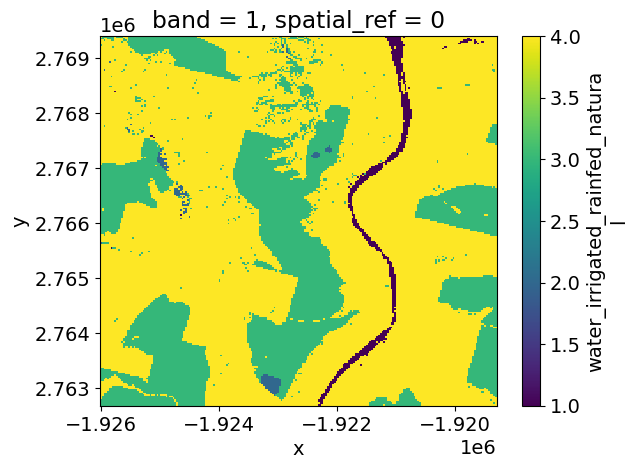

In [88]:
rio.open_rasterio(files[120]).plot(x = 'x')

In [89]:
water = irrigated = rainfed = natural = 0

for file in files:
    data = rio.open_rasterio(file)
    water += data.where(data.isin([1])).count(dim=["x", "y"])
    irrigated += data.where(data.isin([2])).count(dim=["x", "y"])
    rainfed += data.where(data.isin([3])).count(dim=["x", "y"])
    natural += data.where(data.isin([4])).count(dim=["x", "y"])

In [90]:
natural

<xarray.DataArray (band: 1)> Size: 8B
array([93117458])
Coordinates:
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0

In [91]:
import numpy as np
class_counts = np.array([water,irrigated,rainfed,natural])  # Example counts
total_pixels = np.sum(class_counts)
class_counts

array([[ 3602561],
       [16290935],
       [40427254],
       [93117458]])

In [92]:
class_weights = total_pixels / class_counts

In [93]:
class_weights.flatten()

array([42.59142538,  9.41862502,  3.79541504,  1.64779206])